## Proyecto 2 Intoduccion a Los modelos matematicos para el analisis finacnciero


$$ S(t) $$

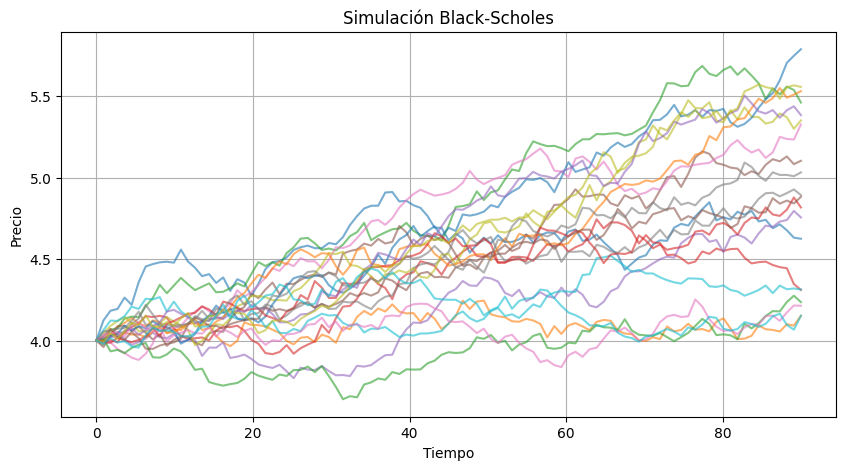

Precio estimado opción ventana: 0.13482970332573313


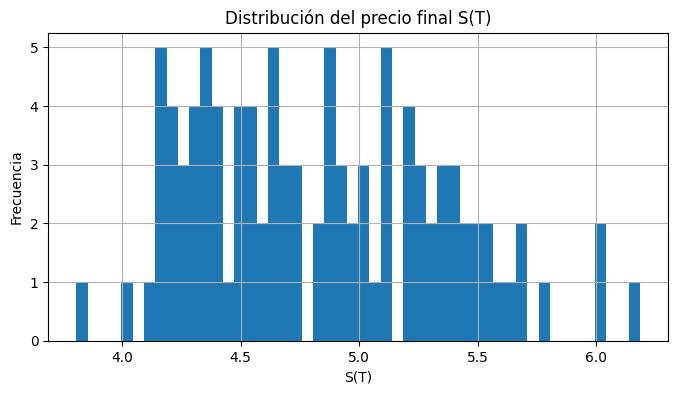

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# 1. Función para simular el precio
# -------------------------------
def simular_black_scholes(S0, mu, sigma, T, N, n_sim):
    dt = T / N
    t = np.linspace(0, T, N+1)
    
    # matriz de resultados
    S = np.zeros((n_sim, N+1))
    S[:, 0] = S0
    
    for i in range(1, N+1):
        Z = np.random.normal(0, 1, n_sim)
        S[:, i] = S[:, i-1] + mu*S[:, i-1]*dt + sigma*S[:, i-1]*np.sqrt(dt)*Z
    
    return t, S


# -------------------------------
# 2. Función opción ventana
# -------------------------------
def opcion_ventana_payoff(S_T, E1, E2, E):
    payoff = np.where((S_T >= E1) & (S_T <= E2), np.maximum(S_T - E, 0), 0)
    return payoff


# -------------------------------
# 3. Parámetros
# -------------------------------
S0 = 4
mu = 0.002
sigma = 0.02 # Rene check
T = 90 # Rene Check
N = 100
n_sim = 100

# opción ventana
E1 = 4.5
E2 = 10
E = 5 # 10^3 dolar, 10^ cop
r = 0.001  # tasa libre de riesgo


# -------------------------------
# 4. Simulación
# -------------------------------
t, S = simular_black_scholes(S0, mu, sigma, T, N, n_sim)

# -------------------------------
# 5. Gráfica de trayectorias
# -------------------------------
plt.figure(figsize=(10,5))
for i in range(20):  # solo algunas para no saturar
    plt.plot(t, S[i], alpha=0.6)

plt.title("Simulación Black-Scholes")
plt.xlabel("Tiempo")
plt.ylabel("Precio")
plt.grid()
plt.show()


# -------------------------------
# 6. Precio de la opción ventana (Monte Carlo)
# -------------------------------
S_T = S[:, -1]
payoffs = opcion_ventana_payoff(S_T, E1, E2, E)

# descuento
precio_opcion = np.exp(-r*T) * np.mean(payoffs)

print("Precio estimado opción ventana:", precio_opcion)


# -------------------------------
# 7. Histograma (riesgo)
# -------------------------------
plt.figure(figsize=(8,4))
plt.hist(S_T, bins=50)
plt.title("Distribución del precio final S(T)")
plt.xlabel("S(T)")
plt.ylabel("Frecuencia")
plt.grid()
plt.show()

#### 2a planter BlackScholes



$$
\frac{\partial C}{\partial t}
+
\frac{1}{2}\sigma^2 S^2
\frac{\partial^2 C}{\partial S^2}
+
rS\frac{\partial C}{\partial S}
-
rC
=
0

$$


$$
dS = \mu Sdt + \sigma SdW
$$

#### 2b Condiciones de frontera

$$
C(S_{T},T) = 

\begin{cases}
    max (S_{t} - E,0) & \text{si } E_{1} \le S_{T}\le E_{2} \\
    0   & \text{d.l.c } 
\end{cases}

$$

$$
C(S_{\infty},T) = 0
$$

$$
C(0,T) = 0
$$

#### 2c resolve ecuacion analiticamente

$$
d_{1}(K) = \frac{ln(\frac{S}{K})+(r+\frac{1}{2}\sigma^{2} \tau)}{\sigma \sqrt{\tau}}
$$


$$
d_{2}(K) = \frac{ln(\frac{S}{K})+(r-\frac{1}{2}\sigma^{2} \tau)}{\sigma \sqrt{\tau}}
$$

$$
Sin commpoenentes aleatorios:
\pi = C - \Delta S

$$
$$
\Delta = \frac{\partial C}{\partial S}


$$

$$
r\pi = \frac{\partial C}{\partial S} + \frac{1}{2} \sigma ^{2} S^{2} \frac{\partial ^{2}C}{\partial S^{2}}
$$

$$


r(C - \frac{\partial C}{\partial S} S) = \frac{\partial C}{\partial S} + \frac{1}{2} \sigma ^{2} S^{2} \frac{\partial ^{2}C}{\partial S^{2}}
$$

$$
0 = \frac{\partial C}{\partial S} + \frac{1}{2} \sigma ^{2} S^{2} + rS\frac{\partial C}{\partial S}  - rC
$$